## Homework
### Author: Tomasz Zapart

## 1 Download data:

data downloaded to the folder "data"

## 2. Put stations data into stations table in DuckDB. This changes rarely, so we treat it as a almost constant file.

In [160]:
import duckdb

In [165]:
db = duckdb.connect("duckdb_trains.db")
db.execute("""
    Create Table stations AS
    Select * FROM read_csv_auto('data/stations-2023-09.csv');
""")

In [166]:
db.sql("""
Select id,
    name_short,
    name_long,
    country,
    printf('%.2f', geo_lat) AS latitude,
    printf('%.2f', geo_lng) AS longitude
From stations
Limit 5;
""")

┌───────┬────────────┬───────────────────────┬─────────┬──────────┬───────────┐
│  id   │ name_short │       name_long       │ country │ latitude │ longitude │
│ int64 │  varchar   │        varchar        │ varchar │ varchar  │  varchar  │
├───────┼────────────┼───────────────────────┼─────────┼──────────┼───────────┤
│   266 │ Den Bosch  │ 's-Hertogenbosch      │ NL      │ 51.69    │ 5.29      │
│   269 │ Dn Bosch O │ 's-Hertogenbosch Oost │ NL      │ 51.70    │ 5.32      │
│   227 │ 't Harde   │ 't Harde              │ NL      │ 52.41    │ 5.89      │
│     8 │ Aachen     │ Aachen Hbf            │ D       │ 50.77    │ 6.09      │
│   818 │ Aachen W   │ Aachen West           │ D       │ 50.78    │ 6.07      │
└───────┴────────────┴───────────────────────┴─────────┴──────────┴───────────┘

## 3. Based on DuckDB tutorial, create tables distances and distances_long. We treat this similarly to stations table.

In [168]:
db.sql("""
    Create Table distances As
    SELECT * FROM read_csv_auto('data/tariff-distances-2022-01.csv');
""")

In [169]:
db.sql("""
    Create Table distances_long as
    Unpivot distances
    on Columns (* Exclude station)
    Into Name other_station Value distance;
""")

In [170]:
db.sql("""
    Create or Replace Table distances_long as
    Select
        station,
        other_station,
        TRY_CAST(distance as double) as distance
    From distances_long
    Where Try_Cast(distance as double) is Not Null;
""")

In [171]:
db.sql("""
    Describe distances_long
""")

┌───────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│  column_name  │ column_type │  null   │   key   │ default │  extra  │
│    varchar    │   varchar   │ varchar │ varchar │ varchar │ varchar │
├───────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ Station       │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ other_station │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ distance      │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
└───────────────┴─────────────┴─────────┴─────────┴─────────┴─────────┘

## 4. Put train disruptions into disruptions table in the Postgres database. We expect this data to change regularly, and thus treat it as a typical OLTP table.

To load "disruptions" I used following script:

for f in data/disruptions*.csv; do

psql -h localhost -U postgres -d postgres -c "\copy disruptions FROM '$f' DELIMITER ',' CSV HEADER";\
done

In [175]:
db.sql("""INSTALL postgres; LOAD postgres;""")
conn_string = "host=localhost user=postgres password=postgres dbname=postgres"
db.sql(f"""
ATTACH IF NOT EXISTS '{conn_string}' AS postgres_db (TYPE postgres);
""")

## Transform train services CSV files into a single Parquet file. Make table services from it. We treat this as a big data batch input, created rarely but regularly for analytics purposes.

In [8]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path

path = Path("data")
files = list(path.glob("services*.csv.gz"))

parquet_file = "data/services.parquet"
df = pd.read_csv(files[0])
final_parquet_table = pa.Table.from_pandas(df)

for file in files[1:]:
    df = pd.read_csv(file)
    final_parquet_table = pa.concat_tables(
        [final_parquet_table, pa.Table.from_pandas(df)]
    )

pq.write_table(final_parquet_table, parquet_file, compression="ZSTD")

In [173]:
db.execute("""
    CREATE TABLE services AS
    SELECT * FROM 'data/services.parquet';
""")

##

## 7.1 How many trains departed from Amsterdam Central station overall?


In [11]:
db.sql("""
    Select Count(Distinct "Service:RDT-ID") as total_departures
    From services
    Where "Stop:Station name" = 'Amsterdam Centraal' And "Stop:Arrival time" Is Null
""")

┌──────────────────┐
│ total_departures │
│      int64       │
├──────────────────┤
│          1087255 │
└──────────────────┘

## 7.2 How many trains departed from Amsterdam Central station overall?


In [176]:
db.sql("""
    Select "Service:Type", Avg(Coalesce("Stop:Arrival delay", 0)) as arrival_avg_delay
    From services
    Group by "Service:Type"
    Order by arrival_avg_delay desc
""")

┌──────────────────────┬────────────────────┐
│     Service:Type     │ arrival_avg_delay  │
│       varchar        │       double       │
├──────────────────────┼────────────────────┤
│ Alpen Express        │ 21.956190476190475 │
│ European Sleeper     │  11.81795070189013 │
│ Krokus Express       │ 11.378378378378379 │
│ Nightjet             │  7.878914118685764 │
│ Eurostar             │  5.598256244983488 │
│ ICE International    │  4.786771586006134 │
│ Thalys               │  4.366045308646701 │
│ Int. Trein           │  3.937334784636915 │
│ Nachttrein           │  3.307267318317042 │
│ Stoomtrein           │  2.285140562248996 │
│     ·                │                 ·  │
│     ·                │                 ·  │
│     ·                │                 ·  │
│ Snelbus i.p.v. trein │                0.0 │
│ Belbus ipv trein     │                0.0 │
│ Bus                  │                0.0 │
│ Taxibus ipv trein    │                0.0 │
│ Metro                │          

## 7.3 What was the most common disruption cause in different years? MODE function may be useful.

In [177]:
db.sql("""
Select Mode(statistical_cause_en) as cause, extract('year' From start_time) as year
From postgres_db.disruptions
Group by year
Order by year DESC;
""")

┌───────────────────┬───────┐
│       cause       │ year  │
│      varchar      │ int64 │
├───────────────────┼───────┤
│ broken down train │  2023 │
│ broken down train │  2022 │
│ broken down train │  2021 │
│ broken down train │  2020 │
│ broken down train │  2019 │
│ broken down train │  2018 │
│ broken down train │  2017 │
│ broken down train │  2016 │
│ broken down train │  2015 │
│ broken down train │  2014 │
│ points failure    │  2013 │
│ points failure    │  2012 │
│ broken down train │  2011 │
├───────────────────┴───────┤
│ 13 rows         2 columns │
└───────────────────────────┘

## 7.4 How many trains started their overall service in any Amsterdam station?

In [138]:
db.sql("""
    Select Count(Distinct "Service:RDT-ID") as total_departures
    From services
    Where "Stop:Station name" Like '%Amsterdam%' And "Stop:Arrival time" Is Null
""")

┌──────────────────┐
│ total_departures │
│      int64       │
├──────────────────┤
│          1233152 │
└──────────────────┘

## 7.5 What fraction of services was run to final destinations outside the Netherlands?

In [179]:
db.sql("""
    Select Cast( Count(Distinct "Service:RDT-ID") / (
        Select Count(Distinct "Service:RDT-ID") From services as "se"
        Left Join "stations" as "st" on st."code" = se."Stop:Station code"
        Where se."Stop:Departure time" is Null
    ) as DOUBLE)
    From services as "se"
    Left Join "stations" as "st" on st."code" = se."Stop:Station code"
    Where se."Stop:Departure time" is Null And st."country" != 'NL'
""")

┌──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ CAST((count(DISTINCT "Service:RDT-ID") / (SELECT count(DISTINCT "Service:RDT-ID") FROM services AS se LEFT JOIN stations AS st ON ((st.code = se."Stop:Station code")) WHERE (se."Stop:Departure time" IS NULL))) AS DOUBLE) │
│                                                                                                            double                                                                                                            │
├──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                                                                                   

## 7.6 What is the largest distance between stations in the Netherlands (code NL)?

In [139]:
db.sql("""
With nl_stations AS (
    Select code
    From stations
    Where "country" = 'NL'
)
    Select Max(d.distance)
    From distances_long d
    Join nl_stations s1 on d."Station" = s1.code
    Join nl_stations s2 on d."other_station" = s2.code;
""")

┌─────────────────┐
│ max(d.distance) │
│     double      │
├─────────────────┤
│           426.0 │
└─────────────────┘

## 7.7 Compare the average arrival delay between different train operators (Service:Company) on a bar plot. Sort them appropriately.

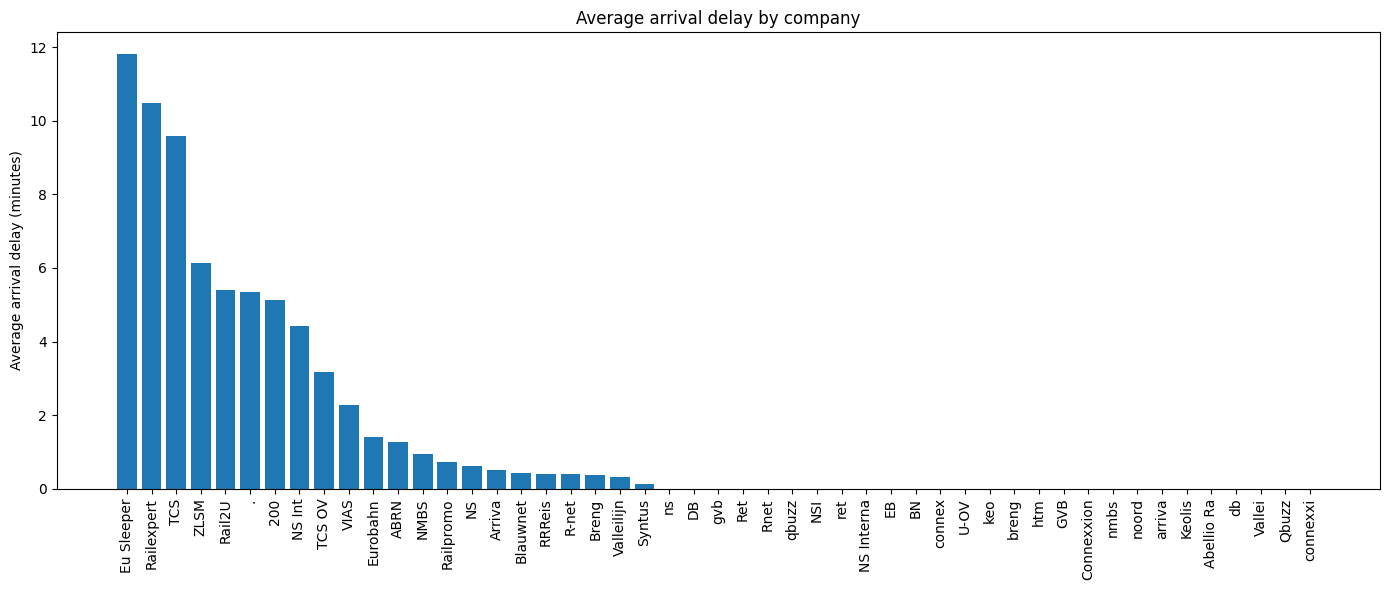

In [180]:
import matplotlib.pyplot as plt

arrival_avg_delay = db.sql("""
    Select "Service:Company" as company, Avg(Coalesce("Stop:Arrival delay", 0)) as arrival_avg_delay From services
    Group by "Service:Company"
    Order by arrival_avg_delay desc
""").df()

plt.figure(figsize=(14, 6))
plt.bar(arrival_avg_delay["company"], arrival_avg_delay["arrival_avg_delay"])
plt.xticks(rotation=90)
plt.ylabel("Average arrival delay (minutes)")

plt.title("Average arrival delay by company")
plt.tight_layout()
plt.show()

## 7.8 How many services were disrupted in different years? Make a line plot.

<Axes: xlabel='year'>

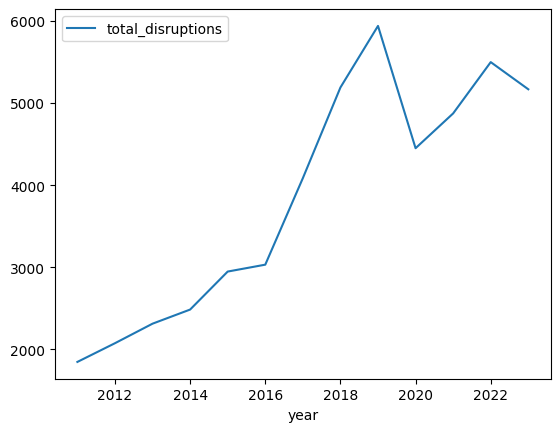

In [181]:
df = db.sql("""
    Select EXTRACT('year' FROM start_time) as year,
    COUNT(*) AS total_disruptions
    From postgres_db.disruptions
    Where "start_time" IS NOT NULL
    Group by year
    Order by year;
""").df()

df.plot.line(x="year", y="total_disruptions")

## 7.9 What fraction of all services were cancelled (Service:Completely cancelled) in different years? Make a line plot.

<Axes: xlabel='year'>

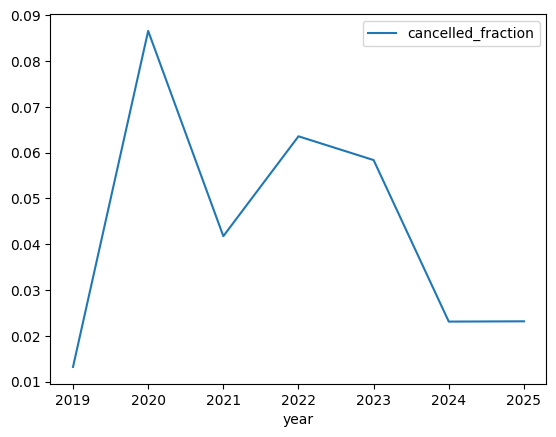

In [182]:
cancelled_fraction = db.sql("""
WITH total_cancelled_in_year AS (
    Select Year(Cast("Service:Date" as TimeStamp)) AS year,
        Count(Distinct "Service:RDT-ID") AS total_cancelled
    From services
    Where "Service:Completely cancelled" = true
    Group by year
),
total AS (
    Select Year(Cast("Service:Date" as TimeStamp)) AS year,
        Count(Distinct "Service:RDT-ID") AS total
    From services
    Group by year
)

SELECT
    t.year AS year,
    COALESCE(c.total_cancelled, 0)::DECIMAL / t.total AS cancelled_fraction
FROM total AS t
LEFT JOIN total_cancelled_in_year AS c
    ON t."year" = c."year"
ORDER BY year;
""").df()

cancelled_fraction.plot.line(x="year", y="cancelled_fraction")

## 8 Currently, services table does not provide information about service lengths, neither between pairs of stations nor for the end-to-end service. Prepare this information:

In [188]:
db.sql("""
Drop Table If Exists station_connections;
Create Table station_connections AS
With next_stops AS (
    Select
        "Service:RDT-ID",
        "Stop:Station code" AS start_station_code,
        Lead("Stop:Station code") Over (
            Partition By "Service:RDT-ID"
            Order By Coalesce("Stop:Departure time", "Stop:Arrival time")
        ) AS end_station_code
    From services
),
station_pairs as (
    Select Distinct "Service:RDT-ID",
        Least(start_station_code, end_station_code) as start_station_code,
        Greatest(start_station_code, end_station_code) as end_station_code
    From next_stops
    Where end_station_code is Not Null
      and start_station_code IS Not Null
)
Select
    "Service:RDT-ID",
    up.start_station_code as start_station_code,
    up.end_station_code as end_station_code,
    Coalesce(d1.distance, d2.distance) AS distance
From station_pairs up
Left Join distances_long d1
    on up.start_station_code = d1.station
   and up.end_station_code = d1.other_station
Left Join distances_long d2
    on up.end_station_code = d2.station
   and up.start_station_code = d2.other_station;
""")

### What is the largest distance between a pair of stations?


In [189]:
db.sql("""
Select Max(distance)
From station_connections
""")

┌───────────────┐
│ max(distance) │
│    double     │
├───────────────┤
│         417.0 │
└───────────────┘

### Plot a histogram of inter-station distances run by trains.

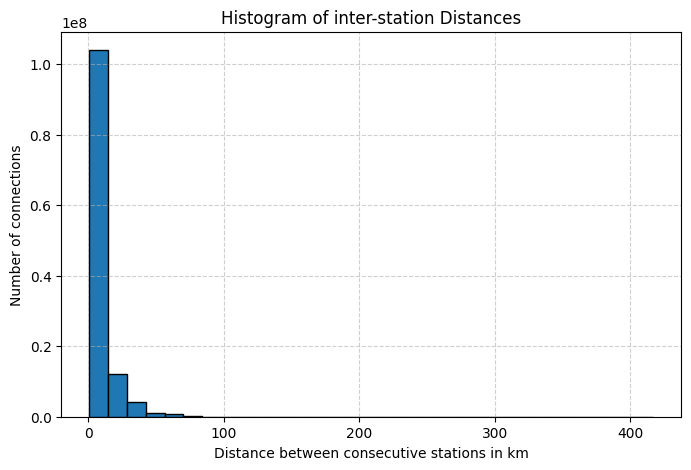

In [190]:
df = db.sql("""
    SELECT distance
    FROM station_connections
    WHERE distance IS NOT NULL
""").df()


plt.figure(figsize=(8, 5))
plt.hist(df["distance"], bins=30, edgecolor="black")
plt.title("Histogram of inter-station Distances")
plt.xlabel("Distance between consecutive stations in km")
plt.ylabel("Number of connections")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()